# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [1]:
!git clone https://github.com/soerenab/AudioMNIST.git

Cloning into 'AudioMNIST'...
remote: Enumerating objects: 30137, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 30137 (delta 9), reused 4 (delta 1), pack-reused 30119 (from 1)
Receiving objects: 100% (30137/30137), 944.54 MiB | 16.54 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Updating files: 100% (30018/30018), done.


In [2]:

import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device:", device)

Available device: cuda


In [5]:
root = 'AudioMNIST/data'
rand_speaker = random.choice(os.listdir(root))
rand_audio = random.choice(os.listdir(os.path.join(root, rand_speaker)))
print(f'Speaker #{rand_speaker}, class #{rand_audio[0]}')

waveform, sample_rate = torchaudio.load(
    os.path.join(root, rand_speaker, rand_audio), normalize=True
)
print(f'Sample rate: {sample_rate}, waveform shape: {waveform.shape}')
Audio(waveform, rate=sample_rate)

Speaker #57, class #0
Sample rate: 48000, waveform shape: torch.Size([1, 40823])


In [6]:

class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label

def collate(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels


# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(root)
_test_dataset[0]

(tensor([[0.0003, 0.0005, 0.0004,  ..., 0.0005, 0.0005, 0.0006]]), 0)

In [7]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

Spectrogram shape: torch.Size([64, 205])
Values range: ((tensor(-18.1884), tensor(-0.4926)))


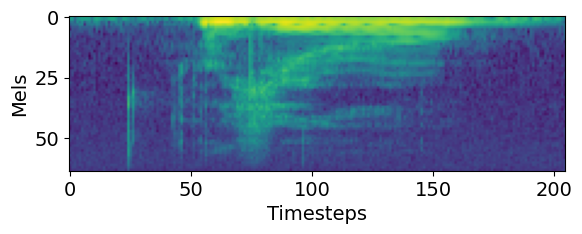

In [8]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
logmel_spec = spectrogram(waveform.squeeze())
print(f'Spectrogram shape: {logmel_spec.shape}')
print(f'Values range: ({logmel_spec.min(), logmel_spec.max()})')

plt.imshow(logmel_spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

In [9]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs


# Split dataset by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)


In [10]:
hyperparameters = {
        'LR': 3e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 10,
        'BATCH_SIZE': 128,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':128,
        'EVAL_EPOCHS':1,
        'MODEL_TITLE': 'contrastive'
}
config = DictConfig(hyperparameters)

# Init dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)


## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

Обучим на спектрограммах. Возьмем ResNet 18 для 2D из семинара

In [11]:
class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

In [12]:
class Classifier(nn.Module):
  def __init__(self, num_classes=10, img_channels=1):
        super().__init__()
        self.encoder = CreateResNet2D(img_channels=img_channels)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
  def forward(self, x):
        features = self.encoder(x)
        output = self.classifier(features)
        return output

In [ ]:
model_supervised = Classifier(num_classes=config.CLASSES, img_channels=config.IMG_CHANNEL).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_supervised.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)

train_losses = []
train_accs = []
val_losses = []
val_accs = []

num_epochs = 5
best_val_acc = 0.0

for epoch in range(num_epochs):
    model_supervised.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    for batch_idx, (audio, labels) in enumerate(pbar):
        audio = audio
        labels = labels.to(device)

        with torch.no_grad():
            spec = spectrogram(audio)
            spec = spec.unsqueeze(1)
            spec = spec.to(device)

        outputs = model_supervised(spec)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{running_loss / (batch_idx + 1):.4f}',
            'acc': f'{100. * correct / total:.2f}%'
        })

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model_supervised.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]  ')
        for audio, labels in pbar:
            # audio = audio
            labels = labels.to(device)

            spec = spectrogram(audio)
            spec = spec.unsqueeze(1)
            spec = spec.to(device)

            outputs = model_supervised(spec)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({
                'loss': f'{val_loss / (pbar.n + 1):.4f}',
                'acc': f'{100. * correct / total:.2f}%'
            })

    val_loss /= len(val_loader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_supervised.state_dict(),
            'val_acc': val_acc,
        }, 'task1_supervised_best.pt')

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%')
    print(f'  Best Val Acc: {best_val_acc:.2f}%\n')



Epoch 1/5 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/5 [Val]  :   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/5:
  Train Loss: 0.1699, Train Acc: 96.42%
  Val Loss:   0.0686, Val Acc:   98.08%
  Best Val Acc: 98.08%



Epoch 2/5 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2/5 [Val]  :   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]  :   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4/5:
  Train Loss: 0.0092, Train Acc: 99.79%
  Val Loss:   0.0848, Val Acc:   97.47%
  Best Val Acc: 98.08%



Epoch 5/5 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 5/5 [Val]  :   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5/5:
  Train Loss: 0.0031, Train Acc: 99.95%
  Val Loss:   0.0774, Val Acc:   98.20%
  Best Val Acc: 98.20%



Модель достигает высокой точности даже на небольшом количестве эпох. Лосс уверенно падает, лучшая accuracy на валидационной выборке - 98.20%

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

Возьмем ResNet 1D и ResNet 2D из семинара

In [13]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet1D():
    return ResNet1D(block)



class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)



In [14]:
class Net(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 35):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        audio = audio.squeeze()
        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms


class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 10):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

In [15]:
def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

Аугментации

In [16]:
def fade_in_out(audio):
    """
    Random fade-in/fade-out, as before but slightly stronger.
    """
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    bs, ch, L = audio.shape
    fade_in_len = random.randint(L // 10, L // 3)
    fade_out_len = random.randint(L // 10, L // 3)
    shape = random.choice(_fade_shape)
    transform = transforms.Fade(fade_in_len=fade_in_len, fade_out_len=fade_out_len, fade_shape=shape)
    return transform(audio)

def add_white_noise_(signal, noise_level=None):
    """
    Add white noise with random intensity.
    """
    if noise_level is None:
        noise_level = random.uniform(0.02, 0.15)
    noise = torch.randn_like(signal) * torch.std(signal) * noise_level
    return signal + noise

def timemasking(waveform, batch_size, sample_rate=16000):
    """
    Time masking — random segment set to 0.
    """
    bs, ch, length = waveform.shape
    mask_len = random.randint(length // 8, length // 4)
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented

def timeshift(audio):
    """
    Random time shift (circular roll).
    """
    bs, ch, L = audio.shape
    shift = random.randint(-L // 10, L // 10)
    return torch.roll(audio, shifts=shift, dims=2)


def frequency_masking(spec, max_mask_freq=8):
    """
    Frequency masking для спектрограмм (зануление частотных полос)
    spec: [B, n_mels, T]
    """
    batch_size, n_mels, time_steps = spec.shape
    masked = spec.clone()

    for i in range(batch_size):
        f = random.randint(0, min(max_mask_freq, n_mels // 8))
        if f > 0:
            f0 = random.randint(0, n_mels - f)
            masked[i, f0:f0 + f, :] = 0.0

    return masked


In [17]:

def create(config):

  # Create model
  model = Net(img_channels=config.IMG_CHANNEL, num_classes = config.CLASSES).to(device)

  # Define the constrastive loss
  loss = ContrastiveLoss()

  mel_transform = LogMelSpectrogram(sample_rate=16000, n_mels=64).to(device)


  # Define the optimizer, the paper use
  optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)

  return model, loss, optimizer, mel_transform


def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):
    scaler = torch.amp.GradScaler()
    epoch_loss_history = []
    epoch_acc_history = []

    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')
        batch_losses = []

        model.train()
        for audio, _ in trainloader:
            optimizer.zero_grad()
            audio = audio.to(device)

            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                audio_emb, spect_emb, _, _ = model(spectograms, audios)
                loss = closs(audio_emb, spect_emb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_losses.append(loss.item())

            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())
            progress_bar.update(1)

        avg_epoch_loss = float(np.mean(batch_losses)) if len(batch_losses) > 0 else float('nan')
        epoch_loss_history.append(avg_epoch_loss)

        # валидируем accuracy через Evaluation Head
        acc = float(evaluationphase(model, valloader, config, mel_transform, stft_trasform))
        epoch_acc_history.append(acc)

        if epoch%5==0:

            torch.save(model.state_dict(), f"model_{config.MODEL_TITLE}.pt")

    return epoch_loss_history, epoch_acc_history

def createModelInput(audio,mel_transform, stft_trasform, augmentation=True):

    audio = audio.unsqueeze(1)


    if augmentation == True:
        audio = fade_in_out(audio)
        audio = timemasking(audio,audio.shape[0])

    # Create the augmented spectograms size [BATCH_SIZE, 3, 200, 200]
    #spectograms = createSpectograms(audio, stft_trasform, mel_transform)
    spectograms = mel_transform(audio)
    spectograms = spectograms.to(device)

    return  spectograms, audio



def evaluationphase(model, val_loader, config, mel_transform, stft_trasform):

    model.eval()
    # Get dataloaders
    # Freeze the gradients for model1
    for param in model.parameters():
        param.requires_grad = False

    def train_head(model, trainloader):

        # Create model
        modelEvaluation = None
        modelEvaluation = EvaluationHead(num_classes = config.CLASSES).to(device)


        optimizer = optim.Adam(modelEvaluation.parameters(), lr=config.LR)

        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(trainloader), unit='step', leave=False)
            losses = []
            for audio,labels in trainloader:
                optimizer.zero_grad()
                audio = audio.to(device)
                # Create augmentation and spectograms!
                spectograms,audios = createModelInput(audio, mel_transform, stft_trasform, augmentation=False)

                labels_cat = torch.cat([labels, labels], dim = 0).to(device)

                # Use frozen encoder
                with torch.no_grad():
                    _, _, frozen_audio, frozen_spects = model(spectograms, audios)

                inputs = torch.cat([frozen_audio, frozen_spects], dim = 0)
                outputs = modelEvaluation(inputs)
                loss = criterion(outputs, labels_cat)

                # Calculate loss and backward
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

                #progress bar stuff
                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=np.mean(losses))  # Update the loss value
                progress_bar.update(1)

            # end for batch


        return modelEvaluation

    def evaluation(model, model_eval, dataloader):
        model_eval.eval()
        progress_bar = tqdm(total=len(dataloader), unit='step')
        total = 0
        correct = 0
        with torch.no_grad():
            for i, (audio,labels) in enumerate(dataloader):

                audio = audio.to(device)
                spectograms,audios = createModelInput(audio, mel_transform, stft_trasform,  augmentation=False)
                labels_cat = torch.cat([labels, labels], dim = 0).to(device)

                # Use frozen encoder
                _, _, frozen_audio, frozen_spects = model(spectograms, audios)
                inputs = torch.cat([frozen_audio, frozen_spects], dim = 0)
                outputs = model_eval(inputs)
                _, predicated = torch.max(outputs.data, 1)
                total += labels_cat.size(0)

                correct += (predicated == labels_cat).sum().item()

                #progress bar stuff
                progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
                progress_bar.update(1)

            # end for batch

        return correct/total


    model_ = train_head(model, train_loader)
    accuracy_test = evaluation(model, model_, val_loader)
    print(f"Accuracy on validation: {accuracy_test}")
    model.train()
    for param in model.parameters():
        param.requires_grad = True

    return accuracy_test


In [ ]:
model, loss_fn, optimizer, mel_transform = create(config)
loss_history, acc_history = train(model, loss_fn, optimizer, train_loader, val_loader, config, mel_transform, None)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Accuracy on validation: 0.54875


  0%|          | 0/188 [00:00<?, ?step/s]

...

Accuracy on validation: 0.6555833333333333


  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Accuracy on validation: 0.6321666666666667


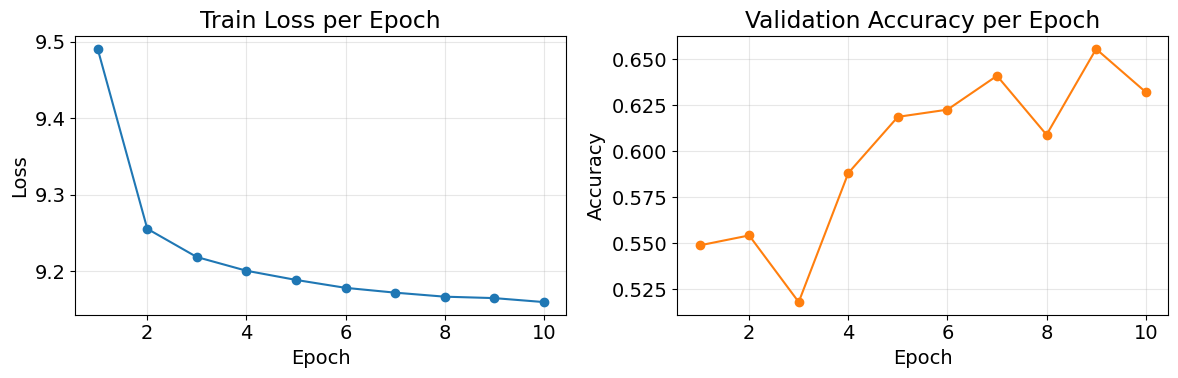

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(loss_history)+1), loss_history, marker='o')
axes[0].set_title('Train Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(acc_history)+1), acc_history, color='tab:orange', marker='o')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

За 10 эпох обучения accuracy достигла значения 0.63 - меньше, чем в supervised. На графике видно, что лосс стабильно падает. Чтобы улучшить результат, можно увеличить число эпох

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


Реализуем SimSiam. В качестве энкодера возьмем ResNet 2D, также реализуем MLP-проектор и предиктор.

Функция потерь основана на косинусном сходстве предсказаний одной augmented-версии с эмбеддингами другой.
Модель обучается в SSL режиме.

В процессе обучения добавлена проверка на коллапс — отслеживаем, не стремятся ли представления к константе (по значению std признаков ).

In [127]:
class SimSiamLoss(nn.Module):
    def __init__(self):
      super().__init__()
    def forward(self,p1, z1, p2, z2):
      p1 = F.normalize(p1, dim=1)
      p2 = F.normalize(p2, dim=1)
      z1 = F.normalize(z1, dim=1)
      z2 = F.normalize(z2, dim=1)
      loss1 = F.cosine_similarity(p1, z2.detach()).mean()
      loss2 = F.cosine_similarity(p2, z1.detach()).mean()
      loss = -0.5 * (loss1 + loss2)

      return loss

In [128]:
class NetSiam(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 10):
      super().__init__()

      self.resnet_2D = CreateResNet2D(img_channels=img_channels)

      self.projector = nn.Sequential(
          nn.Linear(512, 1024, bias=False),
          nn.BatchNorm1d(1024),
          nn.ReLU(inplace=True),
          nn.Linear(1024, 1024, bias=False),
          nn.BatchNorm1d(1024),
          nn.ReLU(inplace=True),
          nn.Linear(1024, 512, bias=False),
          nn.BatchNorm1d(512, affine=False)

      )



      self.predictor = nn.Sequential(
    nn.Linear(512, 256, bias=False),
    nn.ReLU(inplace=True),
    nn.Linear(256, 512, bias=False)
    )




    def forward(self, spec1, spec2,return_projected = False):

      feat1 = self.resnet_2D(spec1)
      feat1 = feat1.squeeze(-1).squeeze(-1)

      feat2 = self.resnet_2D(spec2)
      feat2 = feat2.squeeze(-1).squeeze(-1)

      z1 = self.projector(feat1)
      z2 = self.projector(feat2)

      p1 = self.predictor(z1)
      p2 = self.predictor(z2)


      if return_projected:
        return p1, z1, p2, z2, feat1, feat2
      else:
        return p1, z1, p2, z2

Аугментации

In [129]:
@torch.no_grad()
def createSpectrogramInput(audio, mel_transform, stft_transform=None, augmentation=True):

    audio1 = audio.clone()
    audio2 = audio.clone()

    if augmentation:

        audio1 = fade_in_out(audio1.unsqueeze(1)).squeeze(1)
        audio2 = fade_in_out(audio2.unsqueeze(1)).squeeze(1)

        audio1 = timemasking(audio1.unsqueeze(1),audio1.shape[0]).squeeze(1)
        audio2 = timemasking(audio2.unsqueeze(1),audio2.shape[0]).squeeze(1)

    spec1 = mel_transform(audio1)
    spec2 = mel_transform(audio2)


    spec1 = spec1.unsqueeze(1)
    spec2 = spec2.unsqueeze(1)

    if augmentation:
        spec1 = frequency_masking(spec1.squeeze(1)).unsqueeze(1)
        spec2 = frequency_masking(spec2.squeeze(1)).unsqueeze(1)

    spec1 = spec1 - spec1.mean(dim=(2, 3), keepdim=True)
    spec2 = spec2 - spec2.mean(dim=(2, 3), keepdim=True)

    return spec1.to(device), spec2.to(device)


In [130]:
def create_simsiam(config):

  # Create model
  model = NetSiam(img_channels=config.IMG_CHANNEL, num_classes=config.CLASSES).to(device)

  # Define the constrastive loss
  loss = SimSiamLoss()

  #Define Melspectogram and STFT (Magnitude and Phase)
  mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128,f_min=40, f_max=8000, mel_scale="slaney").to(device)


  optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)

  return model, loss, optimizer, mel_transform

In [131]:
def train_simsiam(model, simsiam_loss, optimizer, trainloader, valloader, config, mel_transform, stft_transform):
    epoch_loss_history = []
    epoch_acc_history = []
    step = 0

    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')
        batch_losses = []

        model.train()
        for audio, _ in trainloader:
            optimizer.zero_grad()
            audio = audio.to(device)

            spec1, spec2 = createSpectrogramInput(audio, mel_transform, augmentation=True)

            p1, z1, p2, z2 = model(spec1, spec2)
            loss = simsiam_loss(p1, z1, p2, z2)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            step += 1

            if step % 100 == 0:
                with torch.no_grad():
                    z1d = F.normalize(z1, dim=1)
                    z_std = z1d.std(dim=0).mean().item()
                if z_std > 0.2 or z_std < 0.03:
                    print(f"\n COLLAPSE DETECTED: step {step}, loss={loss.item():.3f}, z_std={z_std:.4f}")

            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())
            progress_bar.update(1)

        avg_epoch_loss = float(np.mean(batch_losses)) if len(batch_losses) > 0 else float('nan')
        epoch_loss_history.append(avg_epoch_loss)


        if (epoch + 1) % 4 == 0 or epoch == config.EPOCHS - 1:
            acc = float(evaluationphase_simsiam(model, valloader, config, mel_transform, stft_transform))
            epoch_acc_history.append(acc)
            print(f" → Val accuracy: {acc:.4f}")
        else:
            epoch_acc_history.append(epoch_acc_history[-1] if epoch_acc_history else 0.0)

        if epoch% 5 == 0:
            torch.save(model.state_dict(), f"model_{config.MODEL_TITLE}.pt")

    return epoch_loss_history, epoch_acc_history


def evaluationphase_simsiam(model, val_loader, config, mel_transform, stft_transform):
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    def train_head(model, trainloader):
        modelEvaluation = EvaluationHead(num_classes=config.CLASSES).to(device)
        optimizer = optim.Adam(modelEvaluation.parameters(), lr=config.LR)
        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(trainloader), unit='step', leave=False)
            losses = []
            for audio, labels in trainloader:
                optimizer.zero_grad()
                audio = audio.to(device)
                labels = labels.to(device)

                spec1, _ = createSpectrogramInput(audio, mel_transform, augmentation=False)

                with torch.no_grad():
                    feat1 = model.resnet_2D(spec1).squeeze(-1).squeeze(-1)

                outputs = modelEvaluation(feat1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()
                losses.append(loss.item())

                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=np.mean(losses))
                progress_bar.update(1)

        return modelEvaluation

    def evaluation(model, model_eval, dataloader):
        model_eval.eval()
        progress_bar = tqdm(total=len(dataloader), unit='step')
        total = 0
        correct = 0

        with torch.no_grad():
            for i, (audio, labels) in enumerate(dataloader):
                audio = audio.to(device)
                labels = labels.to(device)
                spec1, _ = createSpectrogramInput(audio, mel_transform, augmentation=False)

                feat1 = model.resnet_2D(spec1).squeeze(-1).squeeze(-1)
                outputs = model_eval(feat1)
                _, predicated = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicated == labels).sum().item()

                progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
                progress_bar.update(1)

        return correct / total

    model_ = train_head(model, train_loader)
    accuracy_test = evaluation(model, model_, val_loader)
    print(f"Accuracy on validation: {accuracy_test}")

    model.train()
    for param in model.parameters():
        param.requires_grad = True

    return accuracy_test

In [132]:
hyperparameters = {
        'LR': 3e-4,
        'WEIGHT_DECAY': 1e-4,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 20,
        'BATCH_SIZE': 128,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':128,
        'EVAL_EPOCHS':3,
        'MODEL_TITLE': 'simsiam'
}
config_simsiam = DictConfig(hyperparameters)

In [133]:
model_simsiam, loss_simsiam, optimizer_simsiam, mel_transform_simsiam = create_simsiam(config_simsiam)
loss_history_simsiam, acc_history_simsiam = train_simsiam(
    model_simsiam,
    loss_simsiam,
    optimizer_simsiam,
    train_loader,
    val_loader,
    config_simsiam,
    mel_transform_simsiam,
    None
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

...

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Accuracy on validation: 0.7051666666666667
 → Val accuracy: 0.7052


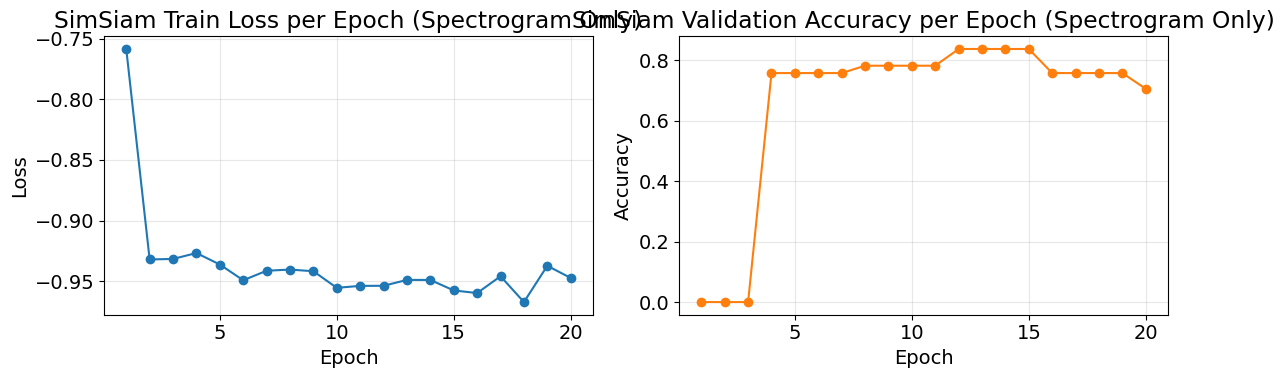


=== SimSiam Training Completed (Spectrogram Encoder Only) ===
Final Train Loss: -0.9473
Final Validation Accuracy: 0.7052


In [134]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(loss_history_simsiam)+1), loss_history_simsiam, marker='o', color='tab:blue')
axes[0].set_title('SimSiam Train Loss per Epoch (Spectrogram Only)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(acc_history_simsiam)+1), acc_history_simsiam, color='tab:orange', marker='o')
axes[1].set_title('SimSiam Validation Accuracy per Epoch (Spectrogram Only)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== SimSiam Training Completed (Spectrogram Encoder Only) ===")
print(f"Final Train Loss: {loss_history_simsiam[-1]:.4f}")
print(f"Final Validation Accuracy: {acc_history_simsiam[-1]:.4f}")

Результаты оказались лучше, чем у InfoNCE. На качество модели сильно влияет нормализация в SimSiamLoss и createSpectrogramInput. Коллапса во время обучения не произошло, лосс колеблется в районе -0.92 - -0.98.

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

Ожидаемо, Supervised training показал лучший результат.

При этом SimSiam оказался лучше, чем InfoNCE.
